# Kernel-Rev vs Kernel-NonRev: Likelihood Computation Analysis

Comparing IQ-TREE 3.1.0 **kernel-rev** (revised kernel) against **kernel-nonrev** (original kernel) across:
- **Data types**: DNA (GTR+I+G4) and Amino Acid (LG+I+G4)
- **Backends**: 1 CPU, 10 CPU, 48 CPU, GPU (V100)
- **Alignment lengths**: 100 to 10,000,000 sites
- **Tree modes**: With starting tree vs No starting tree (de novo)

In [34]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_BASE = '/Users/u7826985/Projects/Nvidia/results/2026_04_02_kernelrev'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_04_02_kernelrev'

# Backend labels
backend_labels = {
    'VANILA': '1 CPU thread',
    'OMP_10': '10 CPU threads',
    'OMP_48': '48 CPU threads',
    'OPENACC': 'GPU (V100)'
}
backend_order = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']

# Kernel labels
kernel_labels = {'kernelrev': 'Kernel-Rev', 'kernelnonrev': 'Kernel-NonRev'}

# Tree mode labels
tree_mode_labels = {'withtree': 'With Tree', 'notree': 'No Tree'}

# Colors for kernel comparison
kernel_colors = {'Kernel-Rev': '#2ca02c', 'Kernel-NonRev': '#d62728'}
kernel_hatches = {'Kernel-Rev': '', 'Kernel-NonRev': '//'}

# Colors for tree mode comparison
tree_mode_colors = {'With Tree': '#1f77b4', 'No Tree': '#ff7f0e'}

# Colors for backends
backend_colors = {
    '1 CPU thread': '#1f77b4',
    '10 CPU threads': '#ff7f0e',
    '48 CPU threads': '#2ca02c',
    'GPU (V100)': '#d62728'
}

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'


## 1. Data Loading and Parsing

In [35]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))

    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))

    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))

    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    # Detect if user tree was provided
    data['has_user_tree'] = 'User tree file name:' in content

    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    data['has_user_tree'] = 'User tree file name:' in content

    return data

def parse_model_table(filepath):
    """Parse the 'List of models sorted by BIC scores' table from .iqtree file."""
    models = []
    with open(filepath, 'r') as f:
        content = f.read()

    table_match = re.search(r'Model\s+LogL\s+AIC.*?BIC.*?\n(.*?)(?:\n\n|\nAkaike|\nBayesian)', content, re.DOTALL)
    if not table_match:
        return models

    for line in table_match.group(1).strip().split('\n'):
        line = line.strip()
        if not line or line.startswith('---'):
            continue
        parts = line.split()
        if len(parts) >= 9:
            try:
                model_name = parts[0]
                lnl = float(parts[1])
                aic = float(parts[2])
                bic = float(parts[-3])
                models.append({'model': model_name, 'lnL': lnl, 'AIC': aic, 'BIC': bic})
            except (ValueError, IndexError):
                continue
    return models

def load_all_results():
    """Load results for all kernel types, tree modes, data types, backends."""
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    data_types = ['DNA', 'AA']

    for data_type in data_types:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir):
                continue

            # 1. With-tree runs: kernelrev and kernelnonrev
            for kernel in ['kernelrev', 'kernelnonrev']:
                for backend in backends:
                    pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.iqtree')
                    iqtree_files = [f for f in glob.glob(pattern) if 'notree' not in os.path.basename(f)]
                    if iqtree_files:
                        data = parse_iqtree_file(iqtree_files[0])
                    else:
                        pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.log')
                        log_files = [f for f in glob.glob(pattern) if 'notree' not in os.path.basename(f)]
                        if log_files:
                            data = parse_log_file(log_files[0])
                        else:
                            continue

                    if not data or 'wall_time_sec' not in data:
                        continue

                    data['length'] = length
                    data['kernel'] = kernel
                    data['kernel_label'] = kernel_labels[kernel]
                    data['backend'] = backend
                    data['backend_label'] = backend_labels[backend]
                    data['data_type'] = data_type
                    data['tree_mode'] = 'With Tree'
                    records.append(data)

            # 2. No-tree runs: kernel-rev (notree without kernelnonrev in name)
            for backend in backends:
                # notree kernel-rev patterns
                patterns_rev = [
                    os.path.join(len_dir, f'output_fulltest_notree_{data_type}_*_{backend}_*.iqtree'),
                    os.path.join(len_dir, f'output_output_fulltest_notree_{data_type}_*_{backend}_*.iqtree'),
                ]
                found_rev = False
                for pat in patterns_rev:
                    files = [f for f in glob.glob(pat) if 'kernelnonrev' not in os.path.basename(f)]
                    if files:
                        data = parse_iqtree_file(files[0])
                        if data and 'wall_time_sec' in data:
                            data['length'] = length
                            data['kernel'] = 'kernelrev'
                            data['kernel_label'] = 'Kernel-Rev'
                            data['backend'] = backend
                            data['backend_label'] = backend_labels[backend]
                            data['data_type'] = data_type
                            data['tree_mode'] = 'No Tree'
                            records.append(data)
                            found_rev = True
                            break

                # notree kernel-nonrev patterns
                patterns_nonrev = [
                    os.path.join(len_dir, f'output_fulltest_notree_kernelnonrev_{data_type}_*_{backend}_*.iqtree'),
                    os.path.join(len_dir, f'output_output_fulltest_notree_kernelnonrev_{data_type}_*_{backend}_*.iqtree'),
                ]
                for pat in patterns_nonrev:
                    files = glob.glob(pat)
                    if files:
                        data = parse_iqtree_file(files[0])
                        if data and 'wall_time_sec' in data:
                            data['length'] = length
                            data['kernel'] = 'kernelnonrev'
                            data['kernel_label'] = 'Kernel-NonRev'
                            data['backend'] = backend
                            data['backend_label'] = backend_labels[backend]
                            data['data_type'] = data_type
                            data['tree_mode'] = 'No Tree'
                            records.append(data)
                            break

    return pd.DataFrame(records)

df_all = load_all_results()
print(f'Total records parsed: {len(df_all)}')
print(f"\nData types: {sorted(df_all['data_type'].unique())}")
print(f"Kernels: {sorted(df_all['kernel_label'].unique())}")
print(f"Backends: {sorted(df_all['backend_label'].unique())}")
print(f"Lengths: {sorted(df_all['length'].unique())}")
print(f"Tree modes: {sorted(df_all['tree_mode'].unique())}")

# Split by tree mode for backward compatibility
df = df_all[df_all['tree_mode'] == 'With Tree'].copy()
df_notree = df_all[df_all['tree_mode'] == 'No Tree'].copy()

df_dna = df[df['data_type'] == 'DNA'].copy()
df_aa = df[df['data_type'] == 'AA'].copy()

df_notree_dna = df_notree[df_notree['data_type'] == 'DNA'].copy()
df_notree_aa = df_notree[df_notree['data_type'] == 'AA'].copy()

print(f'\nWith Tree — DNA: {len(df_dna)}, AA: {len(df_aa)}')
print(f'No Tree   — DNA: {len(df_notree_dna)}, AA: {len(df_notree_aa)}')


Total records parsed: 117

Data types: ['AA', 'DNA']
Kernels: ['Kernel-NonRev', 'Kernel-Rev']
Backends: ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']
Lengths: [100, 1000, 10000, 100000, 1000000]
Tree modes: ['No Tree', 'With Tree']

With Tree — DNA: 24, AA: 24
No Tree   — DNA: 39, AA: 30


In [36]:
# Full summary table
display_cols = ['data_type', 'length', 'kernel_label', 'backend_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
summary = df[display_cols].sort_values(['data_type', 'length', 'backend_label', 'kernel_label']).reset_index(drop=True)
summary['wall_time_fmt'] = summary['wall_time_sec'].apply(fmt_time)
summary['cpu_time_fmt'] = summary['cpu_time_sec'].apply(fmt_time)
print(f"Full results summary ({len(summary)} runs):")
summary

Full results summary (48 runs):


,data_type,length,kernel_label,backend_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec,wall_time_fmt,cpu_time_fmt
0,AA,100,Kernel-NonRev,1 CPU thread,LG+G4,-7.676571e+03,75.74230,75.37500,1.3m,1.3m
1,AA,100,Kernel-Rev,1 CPU thread,LG+G4,-7.676571e+03,44.99000,44.91140,45.0s,44.9s
2,AA,100,Kernel-NonRev,10 CPU threads,LG+G4,-7.676571e+03,37.48470,374.12400,37.5s,6.2m
3,AA,100,Kernel-Rev,10 CPU threads,LG+G4,-7.676571e+03,11.79320,114.76000,11.8s,1.9m
4,AA,100,Kernel-NonRev,48 CPU threads,LG+G4,-7.676571e+03,43.84400,532.23800,43.8s,8.9m
5,AA,100,Kernel-Rev,48 CPU threads,LG+G4,-7.676571e+03,16.59020,206.28400,16.6s,3.4m
6,AA,100,Kernel-NonRev,GPU (V100),LG+G4,-7.676571e+03,83.83120,83.79030,1.4m,1.4m
7,AA,100,Kernel-Rev,GPU (V100),LG+G4,-7.676571e+03,83.89140,83.81470,1.4m,1.4m
8,AA,10000,Kernel-NonRev,1 CPU thread,LG+G4,-8.073514e+05,4404.09000,4251.34000,1.2h,1.2h
9,AA,10000,Kernel-Rev,1 CPU thread,LG+G4,-8.073514e+05,5099.42000,5062.43000,1.4h,1.4h


---
# Part 1: DNA Analysis (GTR+I+G4)

## 2. Model Selection Agreement (DNA)

In [37]:
# Model selection comparison: rev vs nonrev for each backend + length (DNA)
model_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')
print("Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 70)
for length in sorted(df_dna['length'].unique()):
    sub = model_comp_dna.loc[length] if length in model_comp_dna.index.get_level_values(0) else None
    if sub is None: continue
    print(f"\nAlignment length: {length:,}")
    for backend in backend_order:
        if backend in sub.index:
            rev = sub.loc[backend, 'Kernel-Rev'] if 'Kernel-Rev' in sub.columns else 'N/A'
            nonrev = sub.loc[backend, 'Kernel-NonRev'] if 'Kernel-NonRev' in sub.columns else 'N/A'
            match = "MATCH" if rev == nonrev else "DIFFER"
            print(f"  {backend:20s}  Rev: {str(rev):20s}  NonRev: {str(nonrev):20s}  [{match}]")

Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)

Alignment length: 100
  1 CPU thread          Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  10 CPU threads        Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  48 CPU threads        Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  GPU (V100)            Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]

Alignment length: 10,000
  1 CPU thread          Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  10 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  48 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  GPU (V100)            Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]

Alignment length: 100,000
  1 CPU thread          Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  10 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4     

## 3. Log-Likelihood Comparison (DNA)

Check whether kernel-rev and kernel-nonrev produce the same log-likelihood values for each backend and alignment length.

In [38]:
# Log-likelihood comparison: rev vs nonrev (DNA)
lnl_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_dna.columns and 'Kernel-NonRev' in lnl_comp_dna.columns:
    lnl_comp_dna['abs_diff'] = (lnl_comp_dna['Kernel-Rev'] - lnl_comp_dna['Kernel-NonRev']).abs()
    lnl_comp_dna['rel_diff_pct'] = (lnl_comp_dna['abs_diff'] / lnl_comp_dna['Kernel-NonRev'].abs() * 100)

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 90)
lnl_comp_dna.round(4)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length backend_label                                                      
100    1 CPU thread    -4.909972e+03 -4.907728e+03    2.2448        0.0457
       10 CPU threads  -4.909972e+03 -4.907728e+03    2.2448        0.0457
       48 CPU threads  -4.909972e+03 -4.907728e+03    2.2448        0.0457
       GPU (V100)      -4.907728e+03 -4.907728e+03    0.0000        0.0000
10000  1 CPU thread    -5.642088e+05 -5.642088e+05    0.0005        0.0000
       10 CPU threads  -5.642088e+05 -5.642088e+05    0.0001        0.0000
       48 CPU threads  -5.642088e+05 -5.642088e+05    0.0001        0.0000
       GPU (V100)      -5.642088e+05 -5.642088e+05    0.0000        0.0000
100000 1 CPU thread    -5.692985e+06 -5.692985e+06    0.0000        0.0000
       10 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
       48 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
       GPU (V100)      -5.692985e+06 -5.692985e+06    0.0000        0.0000

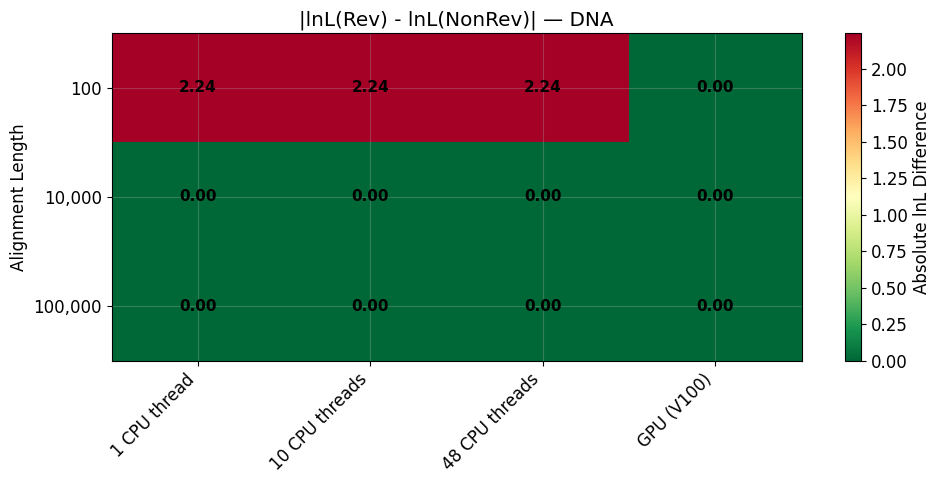

In [39]:
# Log-likelihood difference heatmap (DNA)
if 'abs_diff' in lnl_comp_dna.columns:
    diff_pivot = lnl_comp_dna['abs_diff'].unstack(level='backend_label')
    diff_pivot = diff_pivot[[c for c in backend_order if c in diff_pivot.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot.columns)))
    ax.set_xticklabels(diff_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — DNA')

    for i in range(len(diff_pivot.index)):
        for j in range(len(diff_pivot.columns)):
            val = diff_pivot.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4. Wall-Clock Runtime Comparison (DNA)

Side-by-side wall-clock time: kernel-rev vs kernel-nonrev for each backend.

In [40]:
# Wall-clock time pivot table (DNA)
time_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_dna.columns and 'Kernel-NonRev' in time_comp_dna.columns:
    time_comp_dna['ratio_rev_over_nonrev'] = time_comp_dna['Kernel-Rev'] / time_comp_dna['Kernel-NonRev']
    time_comp_dna['pct_change'] = (time_comp_dna['Kernel-Rev'] - time_comp_dna['Kernel-NonRev']) / time_comp_dna['Kernel-NonRev'] * 100

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
time_comp_dna.round(3)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length backend_label                                                      
100    1 CPU thread            3.364       5.852                  1.740   
       10 CPU threads          8.812       8.859                  1.005   
       48 CPU threads          5.775     146.616                 25.387   
       GPU (V100)             58.542      57.225                  0.977   
10000  1 CPU thread          396.556     427.644                  1.078   
       10 CPU threads         95.905     162.609                  1.696   
       48 CPU threads         53.868      49.935                  0.927   
       GPU (V100)             61.243      62.440                  1.020   
100000 1 CPU thread         3383.543    3848.550                  1.137   
       10 CPU threads        527.334     441.178                  0.837   
       48 CPU threads        208.927     230.140                  1.102   
       GPU (V100)            118.012     118.453                  1.004   

kernel_label           pct_change  
length backend_label               
100    1 CPU thread        73.976  
       10 CPU threads       0.535  
       48 CPU threads    2438.748  
       GPU (V100)          -2.250  
10000  1 CPU thread         7.839  
       10 CPU threads      69.552  
       48 CPU threads      -7.301  
       GPU (V100)           1.954  
100000 1 CPU thread        13.743  
       10 CPU threads     -16.338  
       48 CPU threads      10.153  
       GPU (V100)           0.374

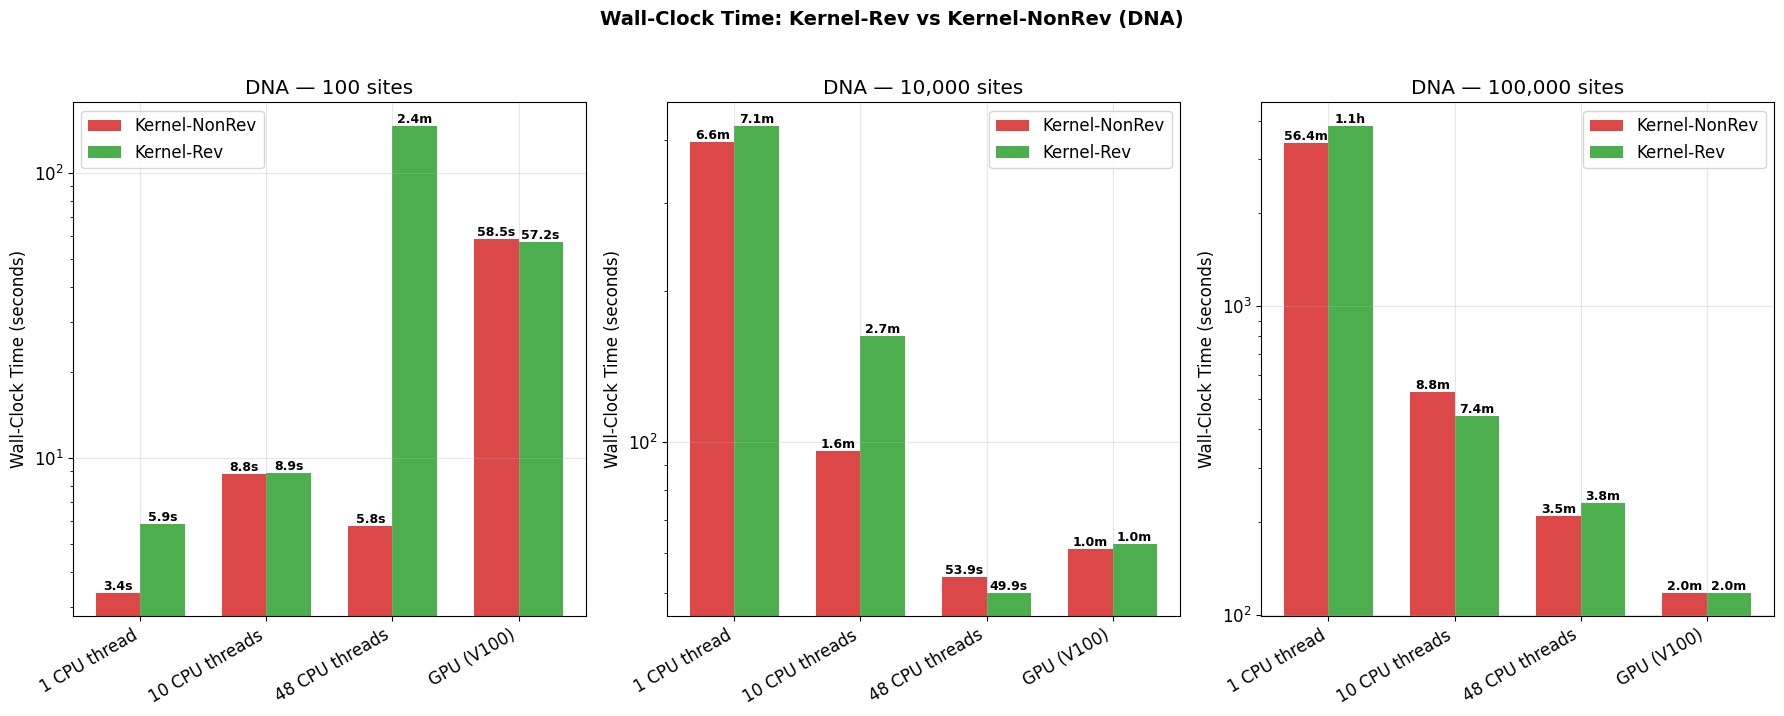

In [41]:
# Grouped bar chart: wall-clock time rev vs nonrev per backend, one subplot per alignment length (DNA)
dna_lengths = sorted(df_dna['length'].unique())
n_lengths = len(dna_lengths)

fig, axes = plt.subplots(1, n_lengths, figsize=(6 * n_lengths, 7), sharey=False)
if n_lengths == 1: axes = [axes]

for ax, length in zip(axes, dna_lengths):
    sub = df_dna[df_dna['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    # Add value labels on bars
    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'DNA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dna_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Ratio: NonRev/Rev (DNA)

Ratio = NonRev_time / Rev_time. Values > 1 mean kernel-rev is faster; < 1 means kernel-nonrev is faster.

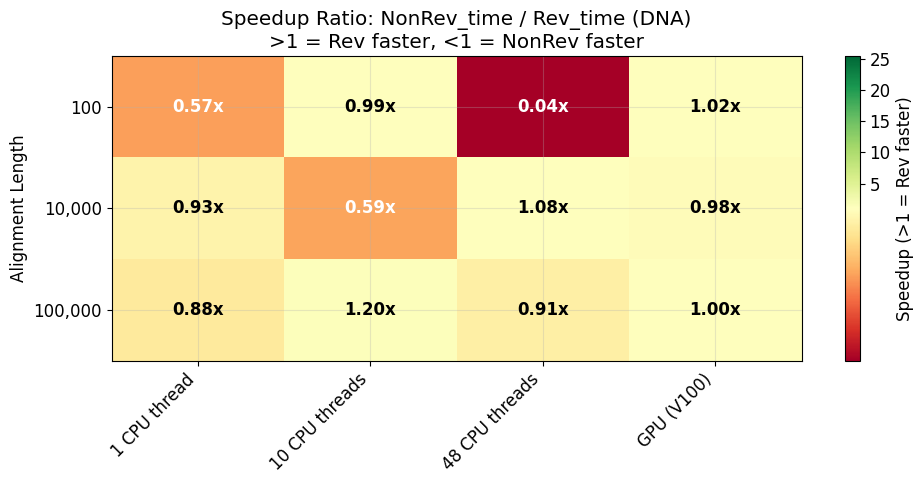

In [42]:
# Speedup heatmap: NonRev_time / Rev_time (DNA)
if 'Kernel-Rev' in time_comp_dna.columns and 'Kernel-NonRev' in time_comp_dna.columns:
    speedup = (time_comp_dna['Kernel-NonRev'] / time_comp_dna['Kernel-Rev']).unstack(level='backend_label')
    speedup = speedup[[c for c in backend_order if c in speedup.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    # Diverging colormap centered at 1.0
    vmin = min(speedup.min().min(), 1/speedup.max().max())
    vmax = max(speedup.max().max(), 1/speedup.min().min())
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup.columns)))
    ax.set_xticklabels(speedup.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (DNA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup.index)):
        for j in range(len(speedup.columns)):
            val = speedup.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison (DNA)

In [43]:
# CPU time comparison (DNA)
cpu_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='cpu_time_sec', aggfunc='first')
if 'Kernel-Rev' in cpu_comp_dna.columns and 'Kernel-NonRev' in cpu_comp_dna.columns:
    cpu_comp_dna['ratio_rev_over_nonrev'] = cpu_comp_dna['Kernel-Rev'] / cpu_comp_dna['Kernel-NonRev']

print("CPU Time (total compute): Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 90)
cpu_comp_dna.round(3)

CPU Time (total compute): Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev
length backend_label                                                   
100    1 CPU thread            3.185       5.761                  1.809
       10 CPU threads         81.789      86.973                  1.063
       48 CPU threads         68.544    2905.680                 42.392
       GPU (V100)             58.108      57.209                  0.985
10000  1 CPU thread          392.644     423.640                  1.079
       10 CPU threads        944.147    1486.960                  1.575
       48 CPU threads       2507.740    2289.060                  0.913
       GPU (V100)             61.174      62.328                  1.019
100000 1 CPU thread         3324.198    3812.075                  1.147
       10 CPU threads       5122.565    4260.559                  0.832
       48 CPU threads       9505.573   10353.240                  1.089
       GPU (V100)            116.553     116.973                  1.004

## 7. Per-Model Log-Likelihood Comparison (DNA)

Compare individual model log-likelihoods between kernel-rev and kernel-nonrev to check numerical consistency.

In [44]:
# Per-model lnL comparison (DNA)
def load_model_details_kernelrev(data_type, lengths_to_use):
    """Load per-model results for rev vs nonrev comparison."""
    all_records = []
    kernels = ['kernelrev', 'kernelnonrev']
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']

    for length in lengths_to_use:
        len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
        if not os.path.isdir(len_dir):
            continue
        for kernel in kernels:
            for backend in backends:
                pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.iqtree')
                iqtree_files = glob.glob(pattern)
                if not iqtree_files:
                    continue
                models = parse_model_table(iqtree_files[0])
                for m in models:
                    m['length'] = length
                    m['kernel'] = kernel
                    m['kernel_label'] = kernel_labels[kernel]
                    m['backend'] = backend
                    m['backend_label'] = backend_labels[backend]
                    all_records.append(m)

    return pd.DataFrame(all_records)

model_df_dna = load_model_details_kernelrev('DNA', sorted(df_dna['length'].unique()))
print(f"Parsed {len(model_df_dna)} model evaluations across DNA runs")

# For each length + backend, compare per-model lnL between rev and nonrev
if len(model_df_dna) > 0:
    # Pivot: for each (length, backend, model), get lnL for rev and nonrev
    comp = model_df_dna.pivot_table(index=['length', 'backend_label', 'model'], columns='kernel_label', values='lnL', aggfunc='first')
    if 'Kernel-Rev' in comp.columns and 'Kernel-NonRev' in comp.columns:
        comp['abs_diff'] = (comp['Kernel-Rev'] - comp['Kernel-NonRev']).abs()
        comp = comp.dropna(subset=['Kernel-Rev', 'Kernel-NonRev'])

        print(f"\nMax |lnL diff| across all models: {comp['abs_diff'].max():.6f}")
        print(f"Mean |lnL diff|: {comp['abs_diff'].mean():.6f}")
        print(f"Models with |diff| > 0.01: {(comp['abs_diff'] > 0.01).sum()} / {len(comp)}")

        # Show worst cases
        worst = comp.nlargest(10, 'abs_diff')
        print("\nTop 10 largest per-model lnL differences (DNA):")
        worst.round(4)

Parsed 2223 model evaluations across DNA runs

Max |lnL diff| across all models: 19.709000
Mean |lnL diff|: 0.498218
Models with |diff| > 0.01: 271 / 816

Top 10 largest per-model lnL differences (DNA):


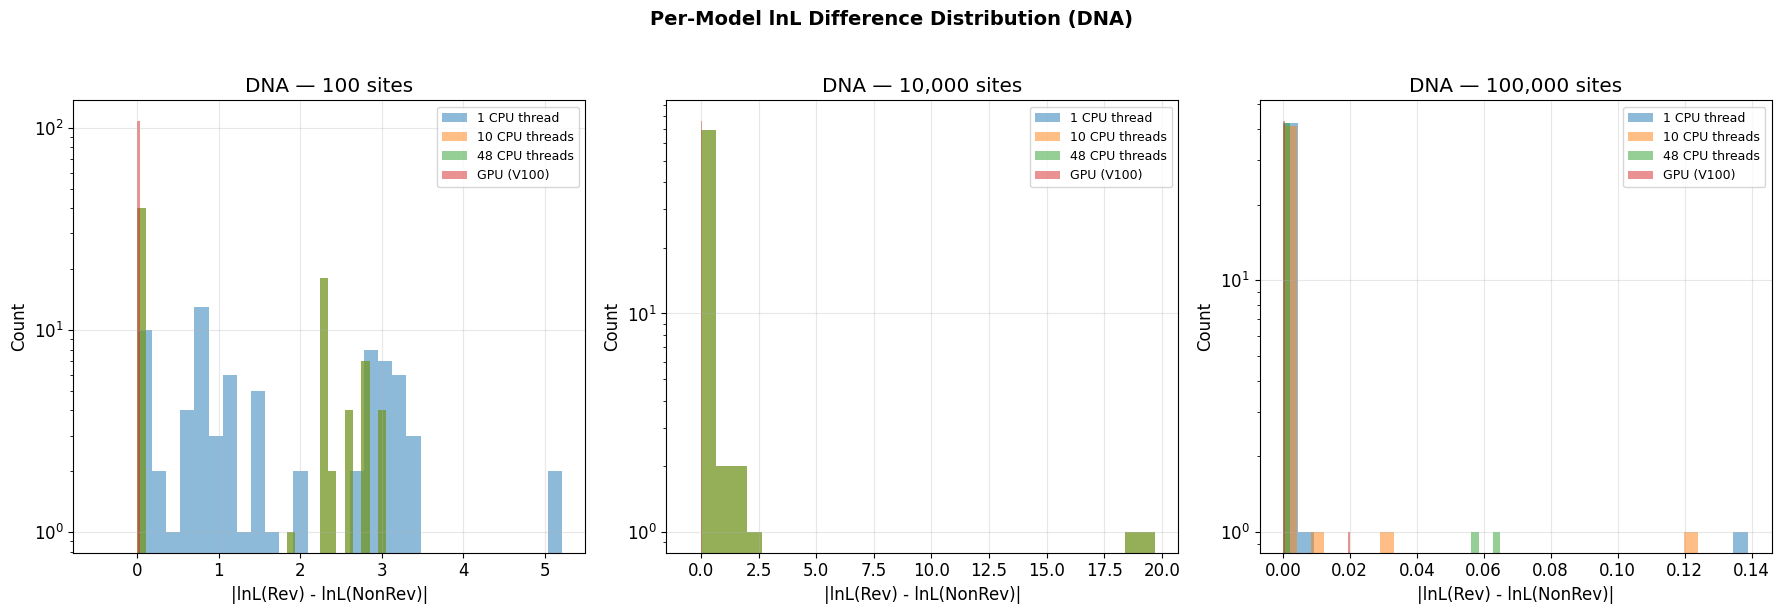

In [45]:
# Per-model lnL difference distribution plot (DNA)
if len(model_df_dna) > 0 and 'abs_diff' in comp.columns:
    fig, axes = plt.subplots(1, len(dna_lengths), figsize=(6 * len(dna_lengths), 6))
    if len(dna_lengths) == 1: axes = [axes]

    for ax, length in zip(axes, dna_lengths):
        sub = comp.loc[length] if length in comp.index.get_level_values(0) else pd.DataFrame()
        if len(sub) == 0: continue

        for backend in backend_order:
            if backend in sub.index.get_level_values(0):
                diffs = sub.loc[backend, 'abs_diff'].values
                ax.hist(diffs, bins=30, alpha=0.5, label=backend, color=backend_colors.get(backend, 'gray'))

        ax.set_xlabel('|lnL(Rev) - lnL(NonRev)|')
        ax.set_ylabel('Count')
        ax.set_title(f'DNA — {length:,} sites')
        ax.legend(fontsize=9)
        ax.set_yscale('log')

    plt.suptitle('Per-Model lnL Difference Distribution (DNA)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_permodel_lnl_dist.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 8. Gamma Shape Alpha Comparison (DNA)

In [46]:
# Gamma shape alpha comparison (DNA)
if 'gamma_alpha' in df_dna.columns:
    gamma_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='gamma_alpha', aggfunc='first')
    if 'Kernel-Rev' in gamma_comp_dna.columns and 'Kernel-NonRev' in gamma_comp_dna.columns:
        gamma_comp_dna['abs_diff'] = (gamma_comp_dna['Kernel-Rev'] - gamma_comp_dna['Kernel-NonRev']).abs()
    print("Gamma Shape Alpha: Kernel-Rev vs Kernel-NonRev (DNA)")
    print("=" * 70)
    display(gamma_comp_dna.round(6))

Gamma Shape Alpha: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev  Kernel-Rev  abs_diff
length backend_label                                      
100    1 CPU thread           0.8627      0.8172    0.0455
       10 CPU threads         0.8627      0.8172    0.0455
       48 CPU threads         0.8627      0.8172    0.0455
       GPU (V100)             0.8172      0.8172    0.0000
10000  1 CPU thread           0.9844      0.9843    0.0001
       10 CPU threads         0.9844      0.9844    0.0000
       48 CPU threads         0.9844      0.9844    0.0000
       GPU (V100)             0.9844      0.9844    0.0000
100000 1 CPU thread           1.0090      1.0090    0.0000
       10 CPU threads         1.0090      1.0090    0.0000
       48 CPU threads         1.0090      1.0090    0.0000
       GPU (V100)             1.0090      1.0090    0.0000

---
# Part 2: Amino Acid Analysis (LG+I+G4)

## 9. Model Selection Agreement (AA)

In [47]:
# Model selection comparison (AA)
model_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')
print("Model Selection: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 70)
for length in sorted(df_aa['length'].unique()):
    sub = model_comp_aa.loc[length] if length in model_comp_aa.index.get_level_values(0) else None
    if sub is None: continue
    print(f"\nAlignment length: {length:,}")
    for backend in backend_order:
        if backend in sub.index:
            rev = sub.loc[backend, 'Kernel-Rev'] if 'Kernel-Rev' in sub.columns else 'N/A'
            nonrev = sub.loc[backend, 'Kernel-NonRev'] if 'Kernel-NonRev' in sub.columns else 'N/A'
            match = "MATCH" if rev == nonrev else "DIFFER"
            print(f"  {backend:20s}  Rev: {str(rev):20s}  NonRev: {str(nonrev):20s}  [{match}]")

Model Selection: Kernel-Rev vs Kernel-NonRev (AA)

Alignment length: 100
  1 CPU thread          Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  48 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  GPU (V100)            Rev: LG+G4                 NonRev: LG+G4                 [MATCH]

Alignment length: 10,000
  1 CPU thread          Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  48 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  GPU (V100)            Rev: LG+G4                 NonRev: LG+G4                 [MATCH]

Alignment length: 100,000
  1 CPU thread          Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4         

## 10. Log-Likelihood Comparison (AA)

In [48]:
# Log-likelihood comparison (AA)
lnl_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_aa.columns and 'Kernel-NonRev' in lnl_comp_aa.columns:
    lnl_comp_aa['abs_diff'] = (lnl_comp_aa['Kernel-Rev'] - lnl_comp_aa['Kernel-NonRev']).abs()
    lnl_comp_aa['rel_diff_pct'] = (lnl_comp_aa['abs_diff'] / lnl_comp_aa['Kernel-NonRev'].abs() * 100)

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 90)
lnl_comp_aa.round(4)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length backend_label                                                      
100    1 CPU thread    -7.676571e+03 -7.676571e+03    0.0000           0.0
       10 CPU threads  -7.676571e+03 -7.676571e+03    0.0000           0.0
       48 CPU threads  -7.676571e+03 -7.676571e+03    0.0000           0.0
       GPU (V100)      -7.676571e+03 -7.676571e+03    0.0000           0.0
10000  1 CPU thread    -8.073514e+05 -8.073514e+05    0.0000           0.0
       10 CPU threads  -8.073514e+05 -8.073514e+05    0.0000           0.0
       48 CPU threads  -8.073514e+05 -8.073514e+05    0.0000           0.0
       GPU (V100)      -8.073514e+05 -8.073514e+05    0.0000           0.0
100000 1 CPU thread    -7.541977e+06 -7.541977e+06    0.0000           0.0
       10 CPU threads  -7.541977e+06 -7.541977e+06    0.0001           0.0
       48 CPU threads  -7.541977e+06 -7.541977e+06    0.0000           0.0
       GPU (V100)      -7.541977e+06 -7.541977e+06    0.0000           0.0

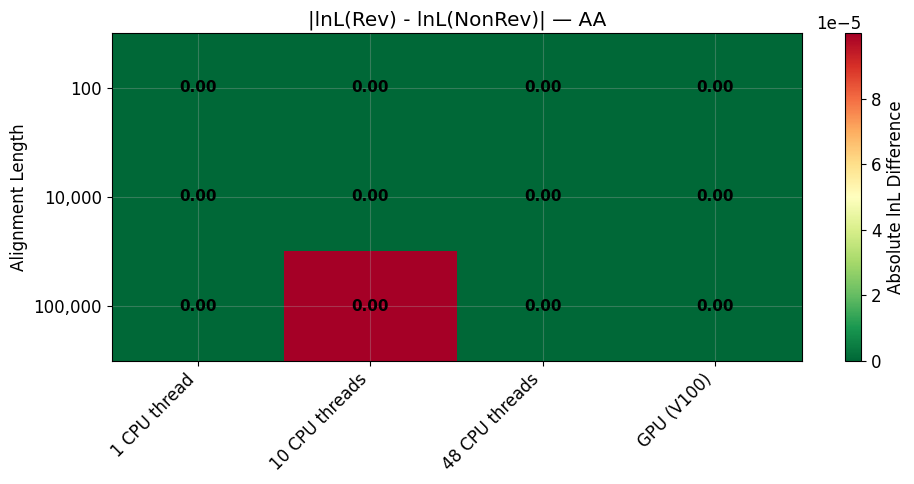

In [49]:
# Log-likelihood difference heatmap (AA)
if 'abs_diff' in lnl_comp_aa.columns:
    diff_pivot_aa = lnl_comp_aa['abs_diff'].unstack(level='backend_label')
    diff_pivot_aa = diff_pivot_aa[[c for c in backend_order if c in diff_pivot_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_aa.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot_aa.columns)))
    ax.set_xticklabels(diff_pivot_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — AA')

    for i in range(len(diff_pivot_aa.index)):
        for j in range(len(diff_pivot_aa.columns)):
            val = diff_pivot_aa.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Wall-Clock Runtime Comparison (AA)

In [50]:
# Wall-clock time pivot table (AA)
time_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_aa.columns and 'Kernel-NonRev' in time_comp_aa.columns:
    time_comp_aa['ratio_rev_over_nonrev'] = time_comp_aa['Kernel-Rev'] / time_comp_aa['Kernel-NonRev']
    time_comp_aa['pct_change'] = (time_comp_aa['Kernel-Rev'] - time_comp_aa['Kernel-NonRev']) / time_comp_aa['Kernel-NonRev'] * 100

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
time_comp_aa.round(3)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length backend_label                                                      
100    1 CPU thread           75.742      44.990                  0.594   
       10 CPU threads         37.485      11.793                  0.315   
       48 CPU threads         43.844      16.590                  0.378   
       GPU (V100)             83.831      83.891                  1.001   
10000  1 CPU thread         4404.090    5099.420                  1.158   
       10 CPU threads        534.524     574.299                  1.074   
       48 CPU threads        278.756     192.261                  0.690   
       GPU (V100)            221.722     222.621                  1.004   
100000 1 CPU thread        32990.030   39534.630                  1.198   
       10 CPU threads       3690.998    4912.561                  1.331   
       48 CPU threads       1288.688    1417.731                  1.100   
       GPU (V100)            959.530     956.770                  0.997   

kernel_label           pct_change  
length backend_label               
100    1 CPU thread       -40.601  
       10 CPU threads     -68.539  
       48 CPU threads     -62.161  
       GPU (V100)           0.072  
10000  1 CPU thread        15.788  
       10 CPU threads       7.441  
       48 CPU threads     -31.029  
       GPU (V100)           0.405  
100000 1 CPU thread        19.838  
       10 CPU threads      33.096  
       48 CPU threads      10.014  
       GPU (V100)          -0.288

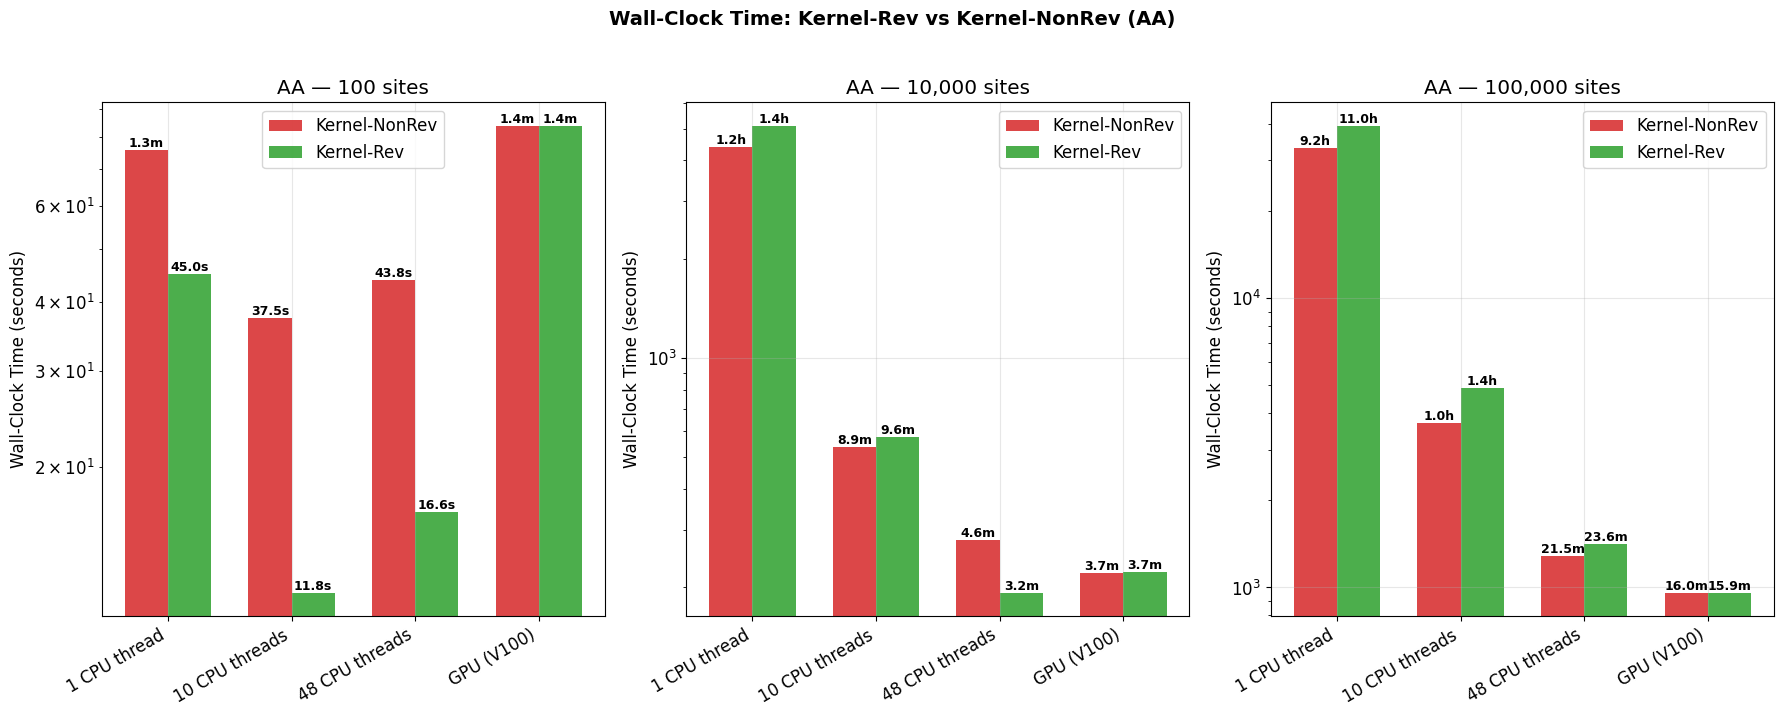

In [51]:
# Grouped bar chart: wall-clock time rev vs nonrev per backend (AA)
aa_lengths = sorted(df_aa['length'].unique())
n_lengths_aa = len(aa_lengths)

fig, axes = plt.subplots(1, n_lengths_aa, figsize=(6 * n_lengths_aa, 7), sharey=False)
if n_lengths_aa == 1: axes = [axes]

for ax, length in zip(axes, aa_lengths):
    sub = df_aa[df_aa['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'AA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'aa_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Speedup Ratio: NonRev/Rev (AA)

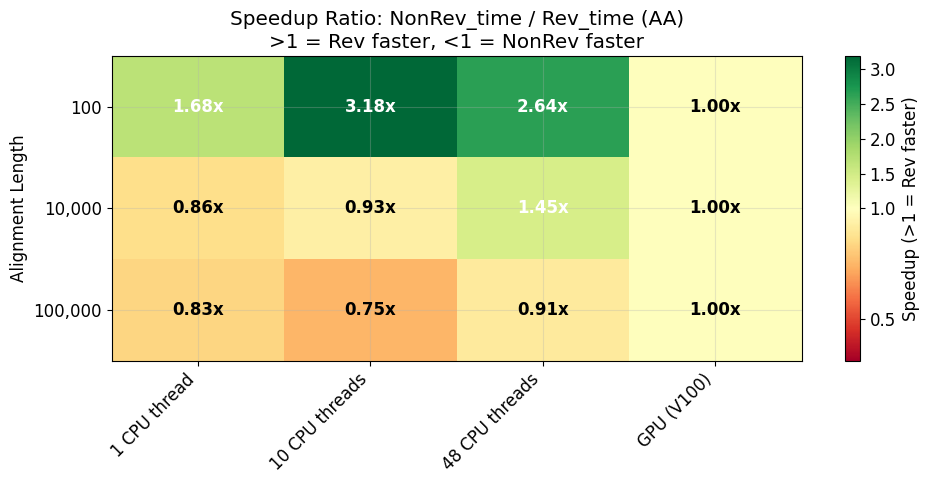

In [52]:
# Speedup heatmap (AA)
if 'Kernel-Rev' in time_comp_aa.columns and 'Kernel-NonRev' in time_comp_aa.columns:
    speedup_aa = (time_comp_aa['Kernel-NonRev'] / time_comp_aa['Kernel-Rev']).unstack(level='backend_label')
    speedup_aa = speedup_aa[[c for c in backend_order if c in speedup_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    from matplotlib.colors import TwoSlopeNorm
    vmin_aa = min(speedup_aa.min().min(), 1/speedup_aa.max().max())
    vmax_aa = max(speedup_aa.max().max(), 1/speedup_aa.min().min())
    norm_aa = TwoSlopeNorm(vmin=vmin_aa, vcenter=1.0, vmax=vmax_aa)

    im = ax.imshow(speedup_aa.values, cmap='RdYlGn', norm=norm_aa, aspect='auto')
    ax.set_xticks(range(len(speedup_aa.columns)))
    ax.set_xticklabels(speedup_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (AA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup_aa.index)):
        for j in range(len(speedup_aa.columns)):
            val = speedup_aa.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 3: No-Tree (De Novo) Analysis

These runs start **without** a user-provided starting tree, performing de novo tree search.
Compare kernel-rev vs kernel-nonrev in this mode.

In [53]:
# No-tree summary
if len(df_notree) > 0:
    display_cols = ['data_type', 'length', 'kernel_label', 'backend_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
    cols = [c for c in display_cols if c in df_notree.columns]
    summary_nt = df_notree[cols].sort_values(['data_type', 'length', 'backend_label', 'kernel_label']).reset_index(drop=True)
    summary_nt['wall_time_fmt'] = summary_nt['wall_time_sec'].apply(fmt_time)
    summary_nt['cpu_time_fmt'] = summary_nt['cpu_time_sec'].apply(fmt_time)
    print(f'No-Tree results summary ({len(summary_nt)} runs):')
    display(summary_nt)
else:
    print('No notree results found.')


No-Tree results summary (69 runs):


,data_type,length,kernel_label,backend_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec,wall_time_fmt,cpu_time_fmt
0,AA,100,Kernel-NonRev,1 CPU thread,LG+G4,-7.670271e+03,679.9740,678.474,11.3m,11.3m
1,AA,100,Kernel-Rev,1 CPU thread,LG+G4,-7.670271e+03,154.8040,154.212,2.6m,2.6m
2,AA,100,Kernel-NonRev,10 CPU threads,LG+G4,-7.670271e+03,462.2040,4569.010,7.7m,1.3h
3,AA,100,Kernel-Rev,10 CPU threads,LG+G4,-7.670271e+03,181.8700,1148.460,3.0m,19.1m
4,AA,100,Kernel-NonRev,48 CPU threads,LG+G4,-7.670271e+03,465.5760,5516.960,7.8m,1.5h
...,...,...,...,...,...,...,...,...,...,...
64,DNA,1000000,Kernel-Rev,10 CPU threads,F81+F+G4,-5.920802e+07,29249.8340,264218.440,8.1h,73.4h
65,DNA,1000000,Kernel-NonRev,48 CPU threads,F81+F+G4,-5.920802e+07,18850.7140,790471.260,5.2h,219.6h
66,DNA,1000000,Kernel-Rev,48 CPU threads,F81+F+G4,-5.920802e+07,16874.4970,698178.190,4.7h,193.9h
67,DNA,1000000,Kernel-NonRev,GPU (V100),F81+F+G4,-5.920802e+07,9799.3471,9672.550,2.7h,2.7h


## 13. No-Tree: Log-Likelihood Comparison (DNA)

Check whether kernel-rev and kernel-nonrev produce similar log-likelihoods when starting from scratch.

In [54]:
# Log-likelihood comparison: no-tree rev vs nonrev (DNA)
if len(df_notree_dna) > 0:
    lnl_nt_dna = df_notree_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
    if 'Kernel-Rev' in lnl_nt_dna.columns and 'Kernel-NonRev' in lnl_nt_dna.columns:
        lnl_nt_dna['abs_diff'] = (lnl_nt_dna['Kernel-Rev'] - lnl_nt_dna['Kernel-NonRev']).abs()
        lnl_nt_dna['rel_diff_pct'] = (lnl_nt_dna['abs_diff'] / lnl_nt_dna['Kernel-NonRev'].abs() * 100)
    print('Log-Likelihood: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)')
    print('=' * 90)
    display(lnl_nt_dna.round(4))


Log-Likelihood: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)


kernel_label            Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length  backend_label                                                      
100     1 CPU thread    -4.896594e+03 -4.894189e+03    2.4047        0.0491
        10 CPU threads  -4.896594e+03 -4.894189e+03    2.4047        0.0491
        48 CPU threads  -4.896594e+03 -4.894189e+03    2.4047        0.0491
        GPU (V100)      -4.894189e+03 -4.894189e+03    0.0000        0.0000
1000    1 CPU thread    -5.618029e+04 -5.618029e+04    0.0000        0.0000
        10 CPU threads  -5.618029e+04 -5.618029e+04    0.0000        0.0000
        48 CPU threads  -5.618029e+04 -5.618029e+04    0.0000        0.0000
        GPU (V100)      -5.618029e+04 -5.618029e+04    0.0001        0.0000
10000   1 CPU thread    -5.642088e+05 -5.642088e+05    0.0000        0.0000
        10 CPU threads  -5.642088e+05 -5.642088e+05    0.0000        0.0000
        48 CPU threads  -5.642088e+05 -5.642088e+05    0.0000        0.0000
        GPU (V100)      -5.642088e+05 -5.642088e+05    0.0003        0.0000
100000  1 CPU thread    -5.692985e+06 -5.692985e+06    0.0000        0.0000
        10 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
        48 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
        GPU (V100)      -5.692985e+06 -5.692985e+06    0.0105        0.0000
1000000 1 CPU thread              NaN -5.920802e+07       NaN           NaN
        10 CPU threads  -5.920802e+07 -5.920802e+07    0.0000        0.0000
        48 CPU threads  -5.920802e+07 -5.920802e+07    0.0000        0.0000
        GPU (V100)      -5.920802e+07 -5.920802e+07    0.0330        0.0000

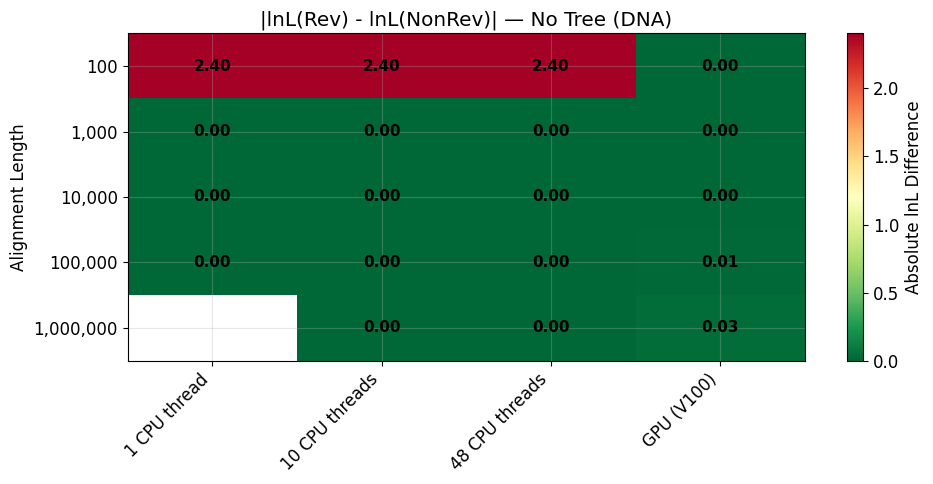

In [55]:
# Log-likelihood difference heatmap — No Tree (DNA)
if len(df_notree_dna) > 0 and 'abs_diff' in lnl_nt_dna.columns:
    diff_pivot_nt = lnl_nt_dna['abs_diff'].unstack(level='backend_label')
    diff_pivot_nt = diff_pivot_nt[[c for c in backend_order if c in diff_pivot_nt.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_nt.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot_nt.columns)))
    ax.set_xticklabels(diff_pivot_nt.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_nt.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_nt.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — No Tree (DNA)')

    for i in range(len(diff_pivot_nt.index)):
        for j in range(len(diff_pivot_nt.columns)):
            val = diff_pivot_nt.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 14. No-Tree: Wall-Clock Runtime Comparison (DNA)

In [56]:
# Wall-clock time: no-tree rev vs nonrev (DNA)
if len(df_notree_dna) > 0:
    time_nt_dna = df_notree_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
    if 'Kernel-Rev' in time_nt_dna.columns and 'Kernel-NonRev' in time_nt_dna.columns:
        time_nt_dna['ratio_rev_over_nonrev'] = time_nt_dna['Kernel-Rev'] / time_nt_dna['Kernel-NonRev']
        time_nt_dna['pct_change'] = (time_nt_dna['Kernel-Rev'] - time_nt_dna['Kernel-NonRev']) / time_nt_dna['Kernel-NonRev'] * 100
    print('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)')
    print('ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER')
    print('=' * 90)
    display(time_nt_dna.round(3))


Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label            Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length  backend_label                                                      
100     1 CPU thread           33.904      21.317                  0.629   
        10 CPU threads         54.317     109.581                  2.017   
        48 CPU threads         94.255     277.338                  2.942   
        GPU (V100)            500.785     463.477                  0.926   
1000    1 CPU thread          101.005      83.333                  0.825   
        10 CPU threads        104.179      47.606                  0.457   
        48 CPU threads        246.726     255.769                  1.037   
        GPU (V100)            312.341     288.248                  0.923   
10000   1 CPU thread         1016.010     898.377                  0.884   
        10 CPU threads        329.612     236.633                  0.718   
        48 CPU threads        291.816     295.304                  1.012   
        GPU (V100)            330.798     350.464                  1.059   
100000  1 CPU thread        10938.190    9299.019                  0.850   
        10 CPU threads       2816.252    1429.382                  0.508   
        48 CPU threads       1226.241     967.302                  0.789   
        GPU (V100)            988.638     960.450                  0.971   
1000000 1 CPU thread              NaN  160646.430                    NaN   
        10 CPU threads      36615.381   29249.834                  0.799   
        48 CPU threads      18850.714   16874.497                  0.895   
        GPU (V100)           9799.347    7071.178                  0.722   

kernel_label            pct_change  
length  backend_label               
100     1 CPU thread       -37.126  
        10 CPU threads     101.744  
        48 CPU threads     194.243  
        GPU (V100)          -7.450  
1000    1 CPU thread       -17.496  
        10 CPU threads     -54.304  
        48 CPU threads       3.665  
        GPU (V100)          -7.714  
10000   1 CPU thread       -11.578  
        10 CPU threads     -28.209  
        48 CPU threads       1.195  
        GPU (V100)           5.945  
100000  1 CPU thread       -14.986  
        10 CPU threads     -49.245  
        48 CPU threads     -21.116  
        GPU (V100)          -2.851  
1000000 1 CPU thread           NaN  
        10 CPU threads     -20.116  
        48 CPU threads     -10.484  
        GPU (V100)         -27.840

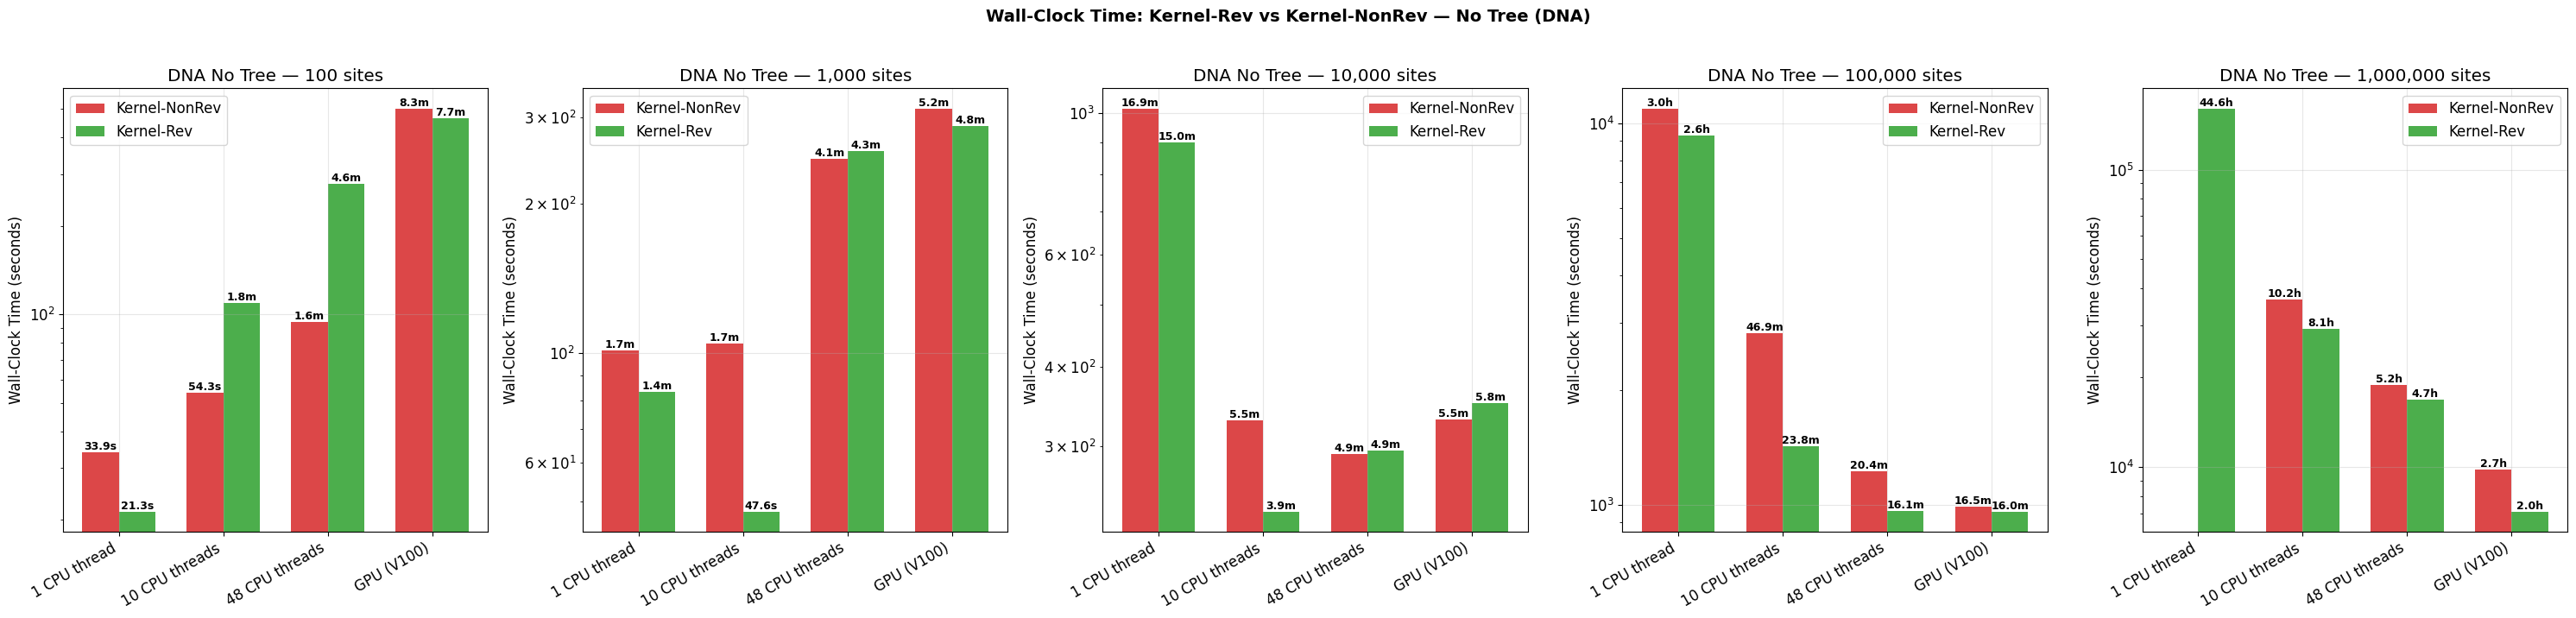

In [57]:
# Grouped bar chart: no-tree wall-clock time (DNA)
if len(df_notree_dna) > 0:
    nt_dna_lengths = sorted(df_notree_dna['length'].unique())
    n_l = len(nt_dna_lengths)
    fig, axes = plt.subplots(1, n_l, figsize=(6 * n_l, 7), sharey=False)
    if n_l == 1: axes = [axes]

    for ax, length in zip(axes, nt_dna_lengths):
        sub = df_notree_dna[df_notree_dna['length'] == length]
        backends_present = [b for b in backend_order if b in sub['backend_label'].values]
        x = np.arange(len(backends_present))
        width = 0.35

        rev_times = []
        nonrev_times = []
        for b in backends_present:
            rv = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
            nrv = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
            rev_times.append(rv.values[0] if len(rv) > 0 else 0)
            nonrev_times.append(nrv.values[0] if len(nrv) > 0 else 0)

        bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
        bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

        for bg in [bars1, bars2]:
            for bar in bg:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h), ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(backends_present, rotation=30, ha='right')
        ax.set_ylabel('Wall-Clock Time (seconds)')
        ax.set_title(f'DNA No Tree — {length:,} sites')
        ax.legend()
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (DNA)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_walltime_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 15. No-Tree: Speedup Ratio (DNA)

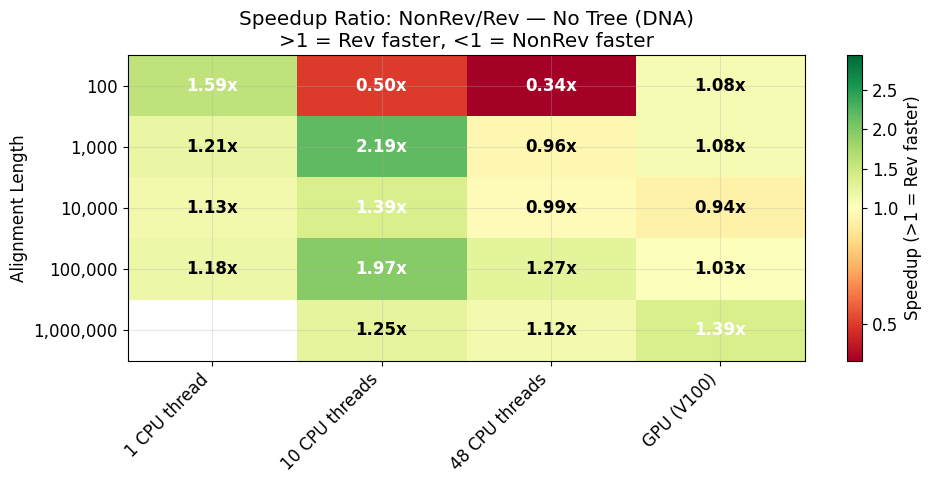

In [58]:
# Speedup heatmap: no-tree (DNA)
if len(df_notree_dna) > 0 and 'Kernel-Rev' in time_nt_dna.columns and 'Kernel-NonRev' in time_nt_dna.columns:
    speedup_nt_dna = (time_nt_dna['Kernel-NonRev'] / time_nt_dna['Kernel-Rev']).unstack(level='backend_label')
    speedup_nt_dna = speedup_nt_dna[[c for c in backend_order if c in speedup_nt_dna.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    from matplotlib.colors import TwoSlopeNorm
    vmin = min(speedup_nt_dna.min().min(), 1/speedup_nt_dna.max().max())
    vmax = max(speedup_nt_dna.max().max(), 1/speedup_nt_dna.min().min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup_nt_dna.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup_nt_dna.columns)))
    ax.set_xticklabels(speedup_nt_dna.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_nt_dna.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_nt_dna.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev/Rev — No Tree (DNA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup_nt_dna.index)):
        for j in range(len(speedup_nt_dna.columns)):
            val = speedup_nt_dna.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_notree_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 16. No-Tree: Log-Likelihood Comparison (AA)

In [59]:
# Log-likelihood comparison: no-tree rev vs nonrev (AA)
if len(df_notree_aa) > 0:
    lnl_nt_aa = df_notree_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
    if 'Kernel-Rev' in lnl_nt_aa.columns and 'Kernel-NonRev' in lnl_nt_aa.columns:
        lnl_nt_aa['abs_diff'] = (lnl_nt_aa['Kernel-Rev'] - lnl_nt_aa['Kernel-NonRev']).abs()
        lnl_nt_aa['rel_diff_pct'] = (lnl_nt_aa['abs_diff'] / lnl_nt_aa['Kernel-NonRev'].abs() * 100)
    print('Log-Likelihood: Kernel-Rev vs Kernel-NonRev — No Tree (AA)')
    print('=' * 90)
    display(lnl_nt_aa.round(4))


Log-Likelihood: Kernel-Rev vs Kernel-NonRev — No Tree (AA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length backend_label                                                      
100    1 CPU thread    -7.670271e+03 -7.670271e+03    0.0000           0.0
       10 CPU threads  -7.670271e+03 -7.670271e+03    0.0000           0.0
       48 CPU threads  -7.670271e+03 -7.670271e+03    0.0000           0.0
       GPU (V100)      -7.670271e+03 -7.670271e+03    0.0000           0.0
1000   1 CPU thread    -7.782396e+04 -7.782396e+04    0.0000           0.0
       10 CPU threads  -7.782396e+04 -7.782396e+04    0.0000           0.0
       48 CPU threads  -7.782396e+04 -7.782396e+04    0.0000           0.0
       GPU (V100)      -7.782396e+04 -7.782396e+04    0.0000           0.0
10000  1 CPU thread    -8.073500e+05 -8.073500e+05    0.0000           0.0
       10 CPU threads  -8.073500e+05 -8.073500e+05    0.0000           0.0
       48 CPU threads  -8.073500e+05 -8.073500e+05    0.0000           0.0
       GPU (V100)      -8.073500e+05 -8.073500e+05    0.0000           0.0
100000 10 CPU threads  -7.541977e+06 -7.541977e+06    0.0028           0.0
       48 CPU threads  -7.541977e+06 -7.541977e+06    0.0001           0.0
       GPU (V100)      -7.541977e+06 -7.541977e+06    0.0000           0.0

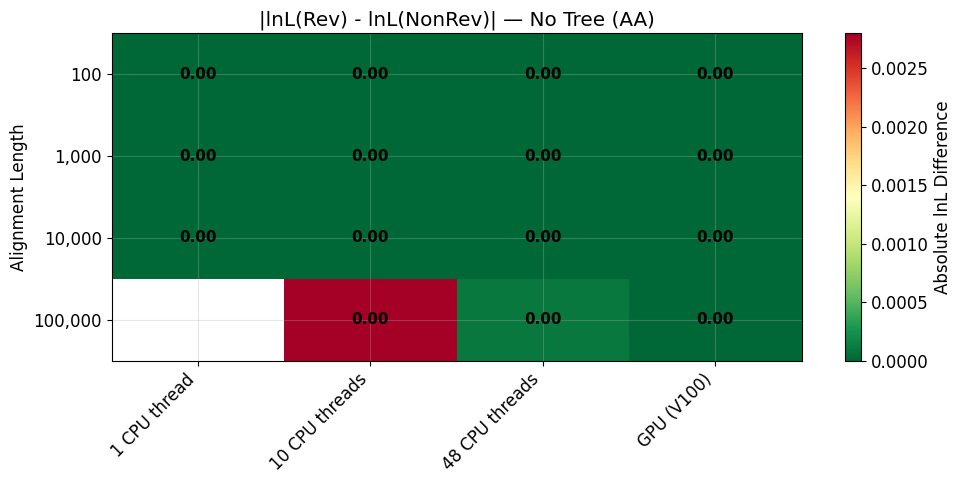

In [60]:
# Log-likelihood difference heatmap — No Tree (AA)
if len(df_notree_aa) > 0 and 'abs_diff' in lnl_nt_aa.columns:
    diff_pivot_nt_aa = lnl_nt_aa['abs_diff'].unstack(level='backend_label')
    diff_pivot_nt_aa = diff_pivot_nt_aa[[c for c in backend_order if c in diff_pivot_nt_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_nt_aa.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot_nt_aa.columns)))
    ax.set_xticklabels(diff_pivot_nt_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_nt_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_nt_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — No Tree (AA)')

    for i in range(len(diff_pivot_nt_aa.index)):
        for j in range(len(diff_pivot_nt_aa.columns)):
            val = diff_pivot_nt_aa.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 17. No-Tree: Wall-Clock Runtime Comparison (AA)

In [61]:
# Wall-clock time: no-tree rev vs nonrev (AA)
if len(df_notree_aa) > 0:
    time_nt_aa = df_notree_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
    if 'Kernel-Rev' in time_nt_aa.columns and 'Kernel-NonRev' in time_nt_aa.columns:
        time_nt_aa['ratio_rev_over_nonrev'] = time_nt_aa['Kernel-Rev'] / time_nt_aa['Kernel-NonRev']
        time_nt_aa['pct_change'] = (time_nt_aa['Kernel-Rev'] - time_nt_aa['Kernel-NonRev']) / time_nt_aa['Kernel-NonRev'] * 100
    print('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (AA)')
    print('ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER')
    print('=' * 90)
    display(time_nt_aa.round(3))


Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (AA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length backend_label                                                      
100    1 CPU thread          679.974     154.804                  0.228   
       10 CPU threads        462.204     181.870                  0.393   
       48 CPU threads        465.576      84.866                  0.182   
       GPU (V100)            543.152     431.915                  0.795   
1000   1 CPU thread         2576.620    1207.190                  0.469   
       10 CPU threads        632.140     325.009                  0.514   
       48 CPU threads        582.933     261.189                  0.448   
       GPU (V100)            482.685     374.877                  0.777   
10000  1 CPU thread        21609.600   11376.100                  0.526   
       10 CPU threads       2605.340    1571.800                  0.603   
       48 CPU threads       1169.630     658.143                  0.563   
       GPU (V100)           1028.440    1017.800                  0.990   
100000 10 CPU threads      22682.080   12406.600                  0.547   
       48 CPU threads       6484.726    4704.717                  0.726   
       GPU (V100)           5820.965    6608.351                  1.135   

kernel_label           pct_change  
length backend_label               
100    1 CPU thread       -77.234  
       10 CPU threads     -60.652  
       48 CPU threads     -81.772  
       GPU (V100)         -20.480  
1000   1 CPU thread       -53.148  
       10 CPU threads     -48.586  
       48 CPU threads     -55.194  
       GPU (V100)         -22.335  
10000  1 CPU thread       -47.356  
       10 CPU threads     -39.670  
       48 CPU threads     -43.731  
       GPU (V100)          -1.035  
100000 10 CPU threads     -45.302  
       48 CPU threads     -27.449  
       GPU (V100)          13.527

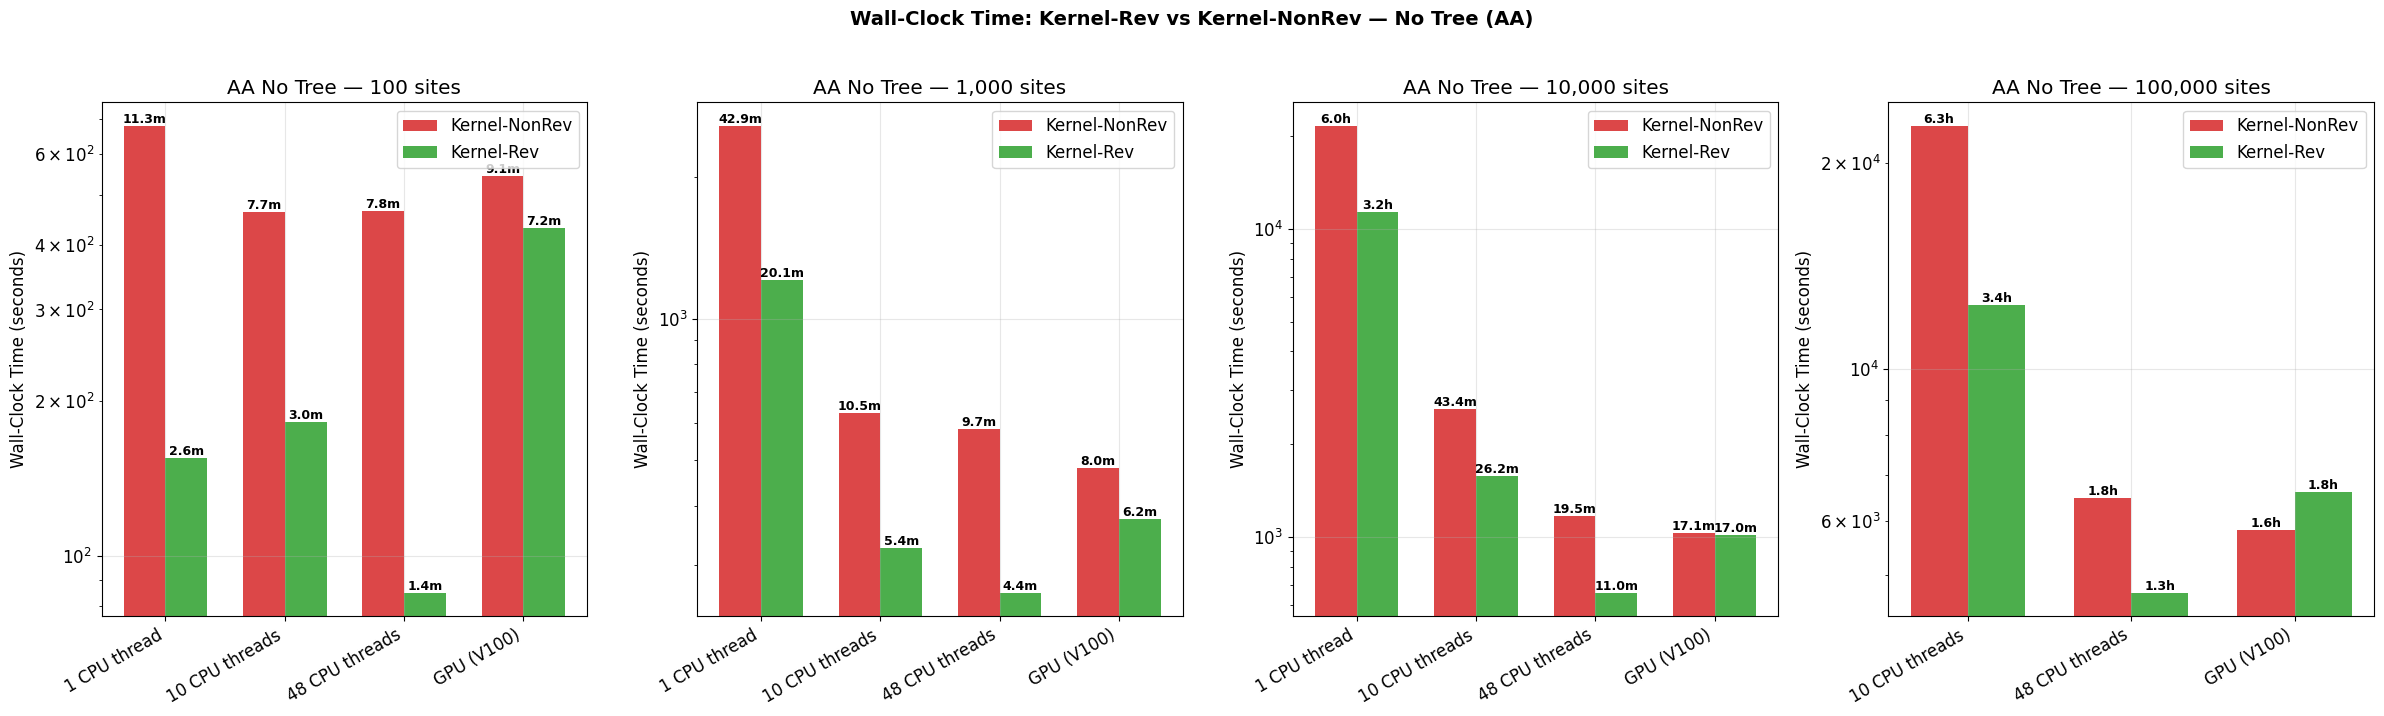

In [62]:
# Grouped bar chart: no-tree wall-clock time (AA)
if len(df_notree_aa) > 0:
    nt_aa_lengths = sorted(df_notree_aa['length'].unique())
    n_l = len(nt_aa_lengths)
    fig, axes = plt.subplots(1, n_l, figsize=(6 * n_l, 7), sharey=False)
    if n_l == 1: axes = [axes]

    for ax, length in zip(axes, nt_aa_lengths):
        sub = df_notree_aa[df_notree_aa['length'] == length]
        backends_present = [b for b in backend_order if b in sub['backend_label'].values]
        x = np.arange(len(backends_present))
        width = 0.35

        rev_times = []
        nonrev_times = []
        for b in backends_present:
            rv = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
            nrv = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
            rev_times.append(rv.values[0] if len(rv) > 0 else 0)
            nonrev_times.append(nrv.values[0] if len(nrv) > 0 else 0)

        bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
        bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

        for bg in [bars1, bars2]:
            for bar in bg:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h), ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(backends_present, rotation=30, ha='right')
        ax.set_ylabel('Wall-Clock Time (seconds)')
        ax.set_title(f'AA No Tree — {length:,} sites')
        ax.legend()
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev — No Tree (AA)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_walltime_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 18. No-Tree: Speedup Ratio (AA)

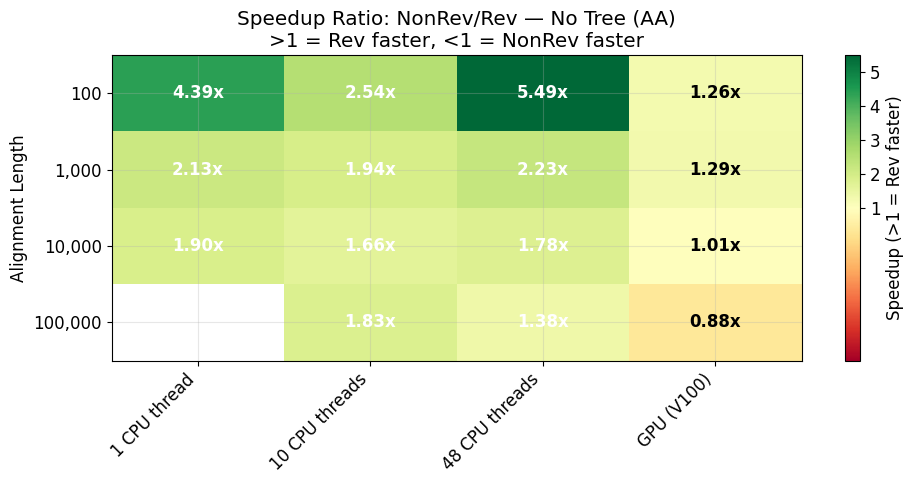

In [63]:
# Speedup heatmap: no-tree (AA)
if len(df_notree_aa) > 0 and 'Kernel-Rev' in time_nt_aa.columns and 'Kernel-NonRev' in time_nt_aa.columns:
    speedup_nt_aa = (time_nt_aa['Kernel-NonRev'] / time_nt_aa['Kernel-Rev']).unstack(level='backend_label')
    speedup_nt_aa = speedup_nt_aa[[c for c in backend_order if c in speedup_nt_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    from matplotlib.colors import TwoSlopeNorm
    vmin = min(speedup_nt_aa.min().min(), 1/speedup_nt_aa.max().max())
    vmax = max(speedup_nt_aa.max().max(), 1/speedup_nt_aa.min().min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup_nt_aa.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup_nt_aa.columns)))
    ax.set_xticklabels(speedup_nt_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_nt_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_nt_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev/Rev — No Tree (AA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup_nt_aa.index)):
        for j in range(len(speedup_nt_aa.columns)):
            val = speedup_nt_aa.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_notree_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


---
# Part 4: With-Tree vs No-Tree Comparison

Compare wall-clock times between runs with a starting tree and de novo (no tree) runs.

In [64]:
# With-tree vs no-tree wall-clock time comparison for Kernel-Rev
def plot_tree_vs_notree(df_tree, df_nt, data_type, kernel_lbl):
    merged = pd.merge(
        df_tree[df_tree['kernel_label'] == kernel_lbl][['length', 'backend_label', 'wall_time_sec']],
        df_nt[df_nt['kernel_label'] == kernel_lbl][['length', 'backend_label', 'wall_time_sec']],
        on=['length', 'backend_label'], suffixes=('_tree', '_notree')
    )
    if len(merged) == 0:
        print(f'No matching data for {data_type} {kernel_lbl}')
        return None

    merged['ratio_notree_over_tree'] = merged['wall_time_sec_notree'] / merged['wall_time_sec_tree']
    merged['wall_fmt_tree'] = merged['wall_time_sec_tree'].apply(fmt_time)
    merged['wall_fmt_notree'] = merged['wall_time_sec_notree'].apply(fmt_time)
    return merged

for dtype, df_t, df_nt in [('DNA', df_dna, df_notree_dna), ('AA', df_aa, df_notree_aa)]:
    for klbl in ['Kernel-Rev', 'Kernel-NonRev']:
        m = plot_tree_vs_notree(df_t, df_nt, dtype, klbl)
        if m is not None and len(m) > 0:
            print(f'\n{dtype} — {klbl}: With-Tree vs No-Tree')
            print(f'ratio > 1 means No-Tree is SLOWER than With-Tree')
            print('=' * 90)
            display(m.round(3))



DNA — Kernel-Rev: With-Tree vs No-Tree
ratio > 1 means No-Tree is SLOWER than With-Tree


,length,backend_label,wall_time_sec_tree,wall_time_sec_notree,ratio_notree_over_tree,wall_fmt_tree,wall_fmt_notree
0,100,1 CPU thread,5.852,21.317,3.643,5.9s,21.3s
1,100,10 CPU threads,8.859,109.581,12.370,8.9s,1.8m
2,100,48 CPU threads,146.616,277.338,1.892,2.4m,4.6m
3,100,GPU (V100),57.225,463.477,8.099,57.2s,7.7m
4,10000,1 CPU thread,427.644,898.377,2.101,7.1m,15.0m
5,10000,10 CPU threads,162.609,236.633,1.455,2.7m,3.9m
6,10000,48 CPU threads,49.935,295.304,5.914,49.9s,4.9m
7,10000,GPU (V100),62.440,350.464,5.613,1.0m,5.8m
8,100000,1 CPU thread,3848.550,9299.019,2.416,1.1h,2.6h
9,100000,10 CPU threads,441.178,1429.382,3.240,7.4m,23.8m



DNA — Kernel-NonRev: With-Tree vs No-Tree
ratio > 1 means No-Tree is SLOWER than With-Tree


,length,backend_label,wall_time_sec_tree,wall_time_sec_notree,ratio_notree_over_tree,wall_fmt_tree,wall_fmt_notree
0,100,1 CPU thread,3.364,33.904,10.080,3.4s,33.9s
1,100,10 CPU threads,8.812,54.317,6.164,8.8s,54.3s
2,100,48 CPU threads,5.775,94.255,16.321,5.8s,1.6m
3,100,GPU (V100),58.542,500.785,8.554,58.5s,8.3m
4,10000,1 CPU thread,396.556,1016.010,2.562,6.6m,16.9m
5,10000,10 CPU threads,95.905,329.612,3.437,1.6m,5.5m
6,10000,48 CPU threads,53.868,291.816,5.417,53.9s,4.9m
7,10000,GPU (V100),61.243,330.798,5.401,1.0m,5.5m
8,100000,1 CPU thread,3383.543,10938.190,3.233,56.4m,3.0h
9,100000,10 CPU threads,527.334,2816.252,5.341,8.8m,46.9m



AA — Kernel-Rev: With-Tree vs No-Tree
ratio > 1 means No-Tree is SLOWER than With-Tree


,length,backend_label,wall_time_sec_tree,wall_time_sec_notree,ratio_notree_over_tree,wall_fmt_tree,wall_fmt_notree
0,100,1 CPU thread,44.990,154.804,3.441,45.0s,2.6m
1,100,10 CPU threads,11.793,181.870,15.422,11.8s,3.0m
2,100,48 CPU threads,16.590,84.866,5.115,16.6s,1.4m
3,100,GPU (V100),83.891,431.915,5.149,1.4m,7.2m
4,10000,1 CPU thread,5099.420,11376.100,2.231,1.4h,3.2h
5,10000,10 CPU threads,574.299,1571.800,2.737,9.6m,26.2m
6,10000,48 CPU threads,192.261,658.143,3.423,3.2m,11.0m
7,10000,GPU (V100),222.621,1017.800,4.572,3.7m,17.0m
8,100000,10 CPU threads,4912.561,12406.600,2.525,1.4h,3.4h
9,100000,48 CPU threads,1417.731,4704.717,3.318,23.6m,1.3h



AA — Kernel-NonRev: With-Tree vs No-Tree
ratio > 1 means No-Tree is SLOWER than With-Tree


,length,backend_label,wall_time_sec_tree,wall_time_sec_notree,ratio_notree_over_tree,wall_fmt_tree,wall_fmt_notree
0,100,1 CPU thread,75.742,679.974,8.977,1.3m,11.3m
1,100,10 CPU threads,37.485,462.204,12.330,37.5s,7.7m
2,100,48 CPU threads,43.844,465.576,10.619,43.8s,7.8m
3,100,GPU (V100),83.831,543.152,6.479,1.4m,9.1m
4,10000,1 CPU thread,4404.090,21609.600,4.907,1.2h,6.0h
5,10000,10 CPU threads,534.524,2605.340,4.874,8.9m,43.4m
6,10000,48 CPU threads,278.756,1169.630,4.196,4.6m,19.5m
7,10000,GPU (V100),221.722,1028.440,4.638,3.7m,17.1m
8,100000,10 CPU threads,3690.998,22682.080,6.145,1.0h,6.3h
9,100000,48 CPU threads,1288.688,6484.726,5.032,21.5m,1.8h


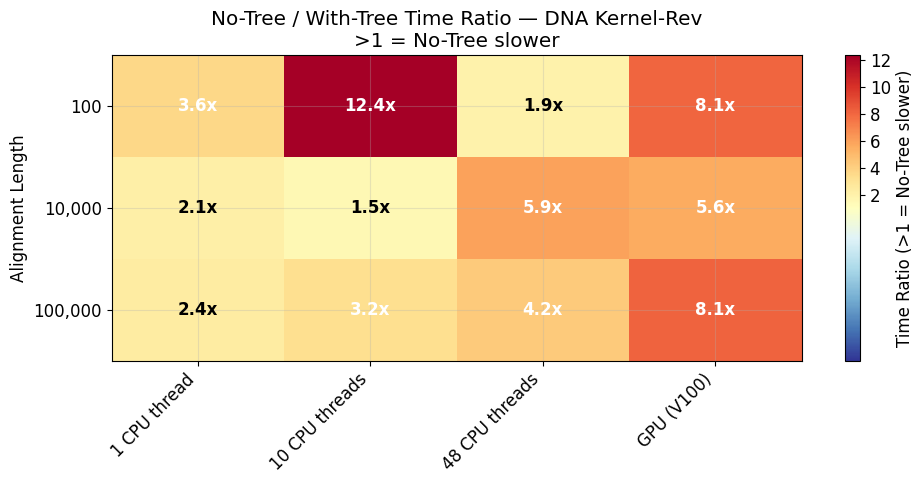

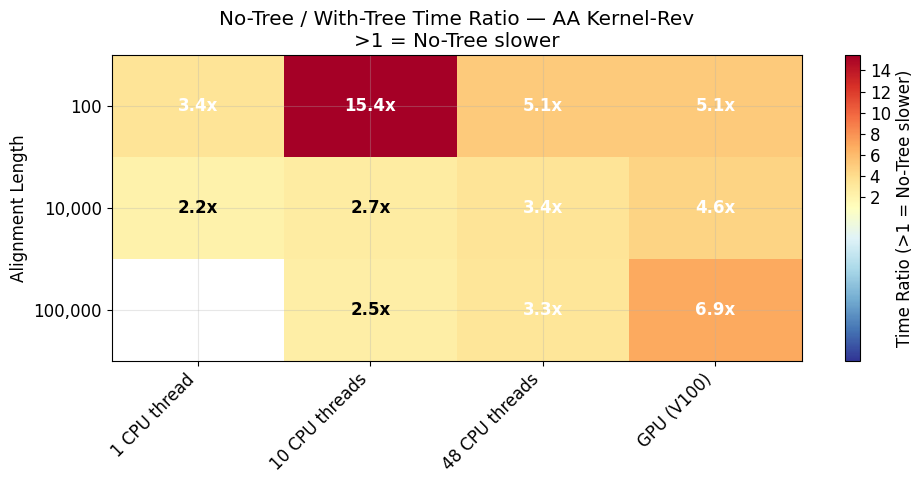

In [65]:
# Combined heatmap: No-Tree slowdown factor over With-Tree for Kernel-Rev
for dtype, df_t, df_nt in [('DNA', df_dna, df_notree_dna), ('AA', df_aa, df_notree_aa)]:
    m = plot_tree_vs_notree(df_t, df_nt, dtype, 'Kernel-Rev')
    if m is None or len(m) == 0:
        continue

    pivot = m.pivot_table(index='length', columns='backend_label', values='ratio_notree_over_tree')
    pivot = pivot[[c for c in backend_order if c in pivot.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    from matplotlib.colors import TwoSlopeNorm
    vmin = min(pivot.min().min(), 1/pivot.max().max())
    vmax = max(pivot.max().max(), 1/pivot.min().min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(pivot.values, cmap='RdYlBu_r', norm=norm, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{l:,}' for l in pivot.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title(f'No-Tree / With-Tree Time Ratio — {dtype} Kernel-Rev\n>1 = No-Tree slower')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 2 else 'black'
                ax.text(j, i, f'{val:.1f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Time Ratio (>1 = No-Tree slower)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_tree_vs_notree_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 19. Combined Speedup: All Backends Across Lengths

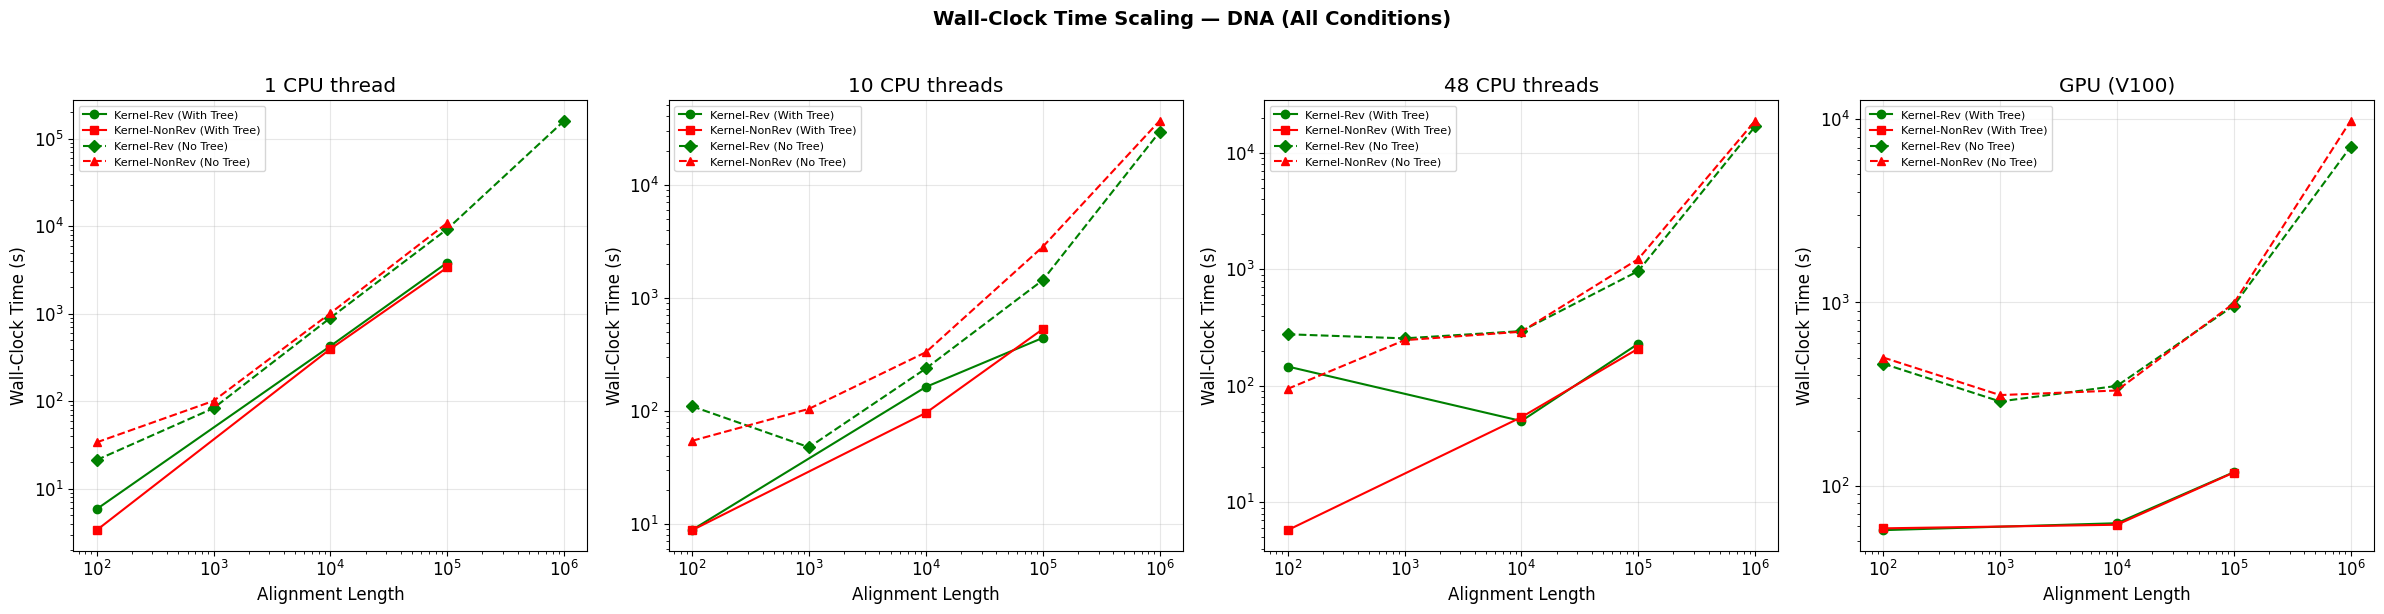

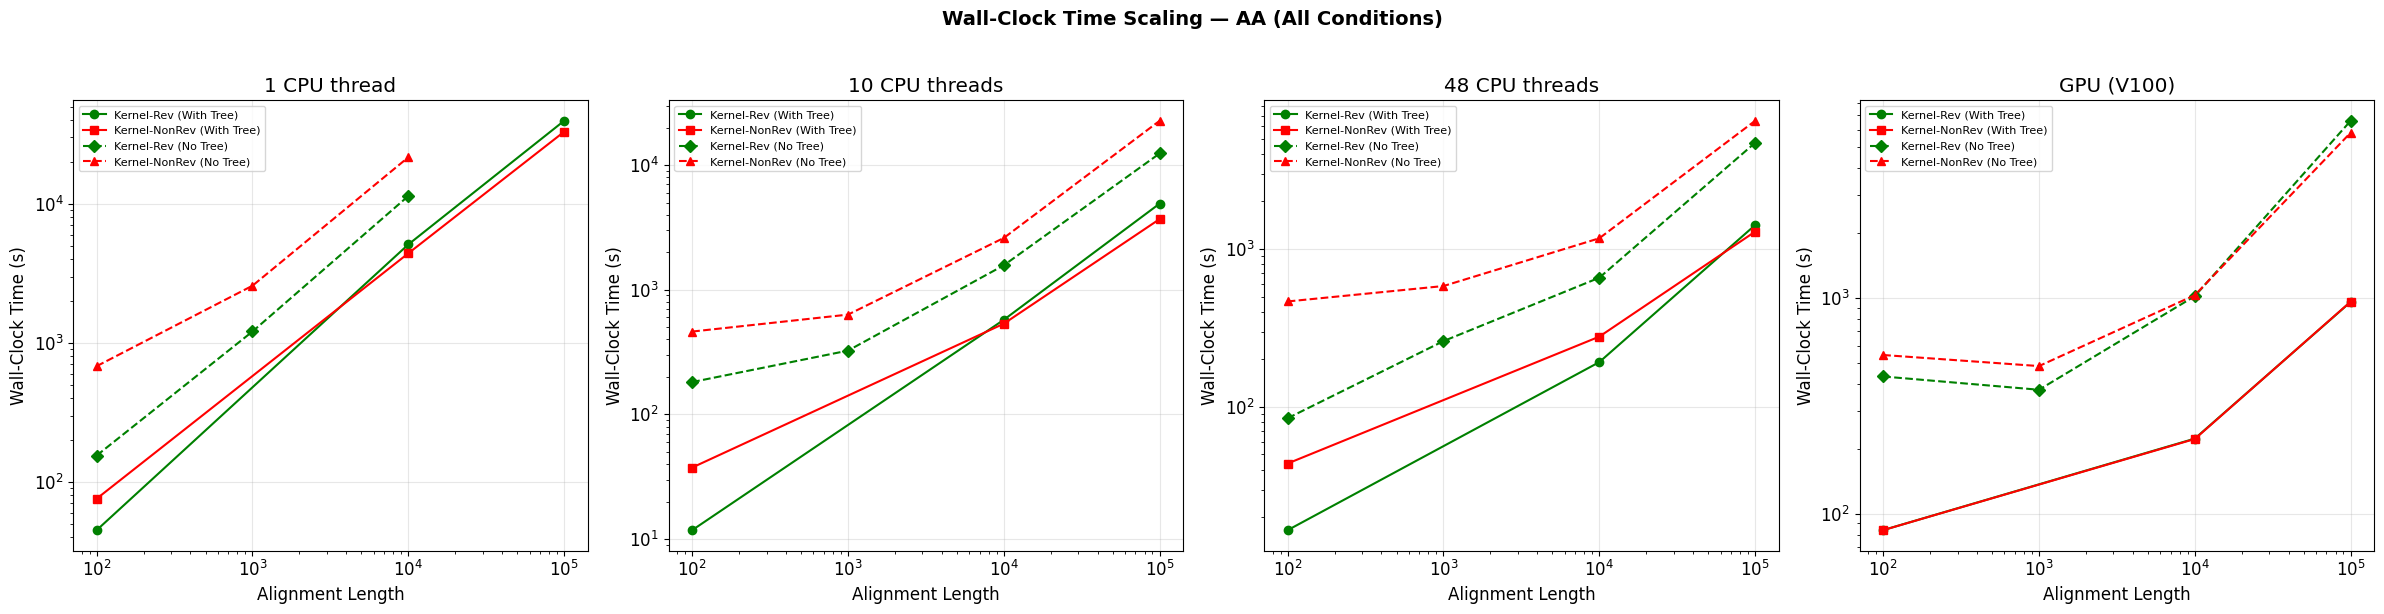

In [66]:
# Combined wall-time line plot: all four conditions (tree/notree x rev/nonrev)
for dtype in ['DNA', 'AA']:
    sub = df_all[df_all['data_type'] == dtype]
    if len(sub) == 0:
        continue

    fig, axes = plt.subplots(1, len(backend_order), figsize=(6 * len(backend_order), 6), sharey=False)

    for ax, backend in zip(axes, backend_order):
        bsub = sub[sub['backend_label'] == backend]
        if len(bsub) == 0:
            ax.set_visible(False)
            continue

        styles = {
            ('Kernel-Rev', 'With Tree'): ('green', '-', 'o'),
            ('Kernel-NonRev', 'With Tree'): ('red', '-', 's'),
            ('Kernel-Rev', 'No Tree'): ('green', '--', 'D'),
            ('Kernel-NonRev', 'No Tree'): ('red', '--', '^'),
        }

        for (klbl, tmode), (color, ls, marker) in styles.items():
            d = bsub[(bsub['kernel_label'] == klbl) & (bsub['tree_mode'] == tmode)].sort_values('length')
            if len(d) > 0:
                ax.plot(d['length'], d['wall_time_sec'], color=color, linestyle=ls, marker=marker,
                        label=f'{klbl} ({tmode})', markersize=6, linewidth=1.5)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Alignment Length')
        ax.set_ylabel('Wall-Clock Time (s)')
        ax.set_title(backend)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Wall-Clock Time Scaling — {dtype} (All Conditions)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{dtype.lower()}_all_conditions_walltime_lines.png'), dpi=150, bbox_inches='tight')
    plt.show()
